# A2 - CNN -> ResNet on MNIST (raccoon's trunk)

**Goal.** Build intuition for the **residual block** - the exact building block of
raccoon's network trunk (`raccoon/model/network.py`).

A residual block is `conv -> BN -> relu -> conv -> BN -> (+ input) -> relu`. The
**skip connection** (`+ input`) lets gradients flow straight through, so deep
stacks train easily. We reuse this block all the way into the AlphaZero net (B4).

In [1]:
import inspect
from azl.foundations import blocks
print(inspect.getsource(blocks.ResidualBlock))

class ResidualBlock(nn.Module):
    """Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> (+ skip) -> ReLU.

    The skip connection lets gradients flow straight through, which is *why*
    deep stacks of these train so much more easily than a plain conv tower.
    Spatial size is preserved (padding=1), so blocks can be stacked freely.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out + residual)  # the skip connection
        return out



In [2]:
import matplotlib.pyplot as plt
import torch

from azl.foundations.data import mnist_loaders
from azl.foundations.models import SmallResNet
from azl.foundations.train_loop import fit, count_parameters

torch.manual_seed(0)
# Bigger subset + an extra epoch so the ResNet clearly clears the MLP from A1.
train_loader, test_loader = mnist_loaders(batch_size=128, view="image", num_train=24000)

net = SmallResNet(channels=32, num_blocks=3, num_classes=10)
print(f"{count_parameters(net):,} parameters")
history = fit(net, train_loader, test_loader, epochs=4, lr=1e-3)

56,362 parameters


epoch  1/4  train_loss 1.1650  val_loss 0.7526  val_acc 0.7341


epoch  2/4  train_loss 0.3032  val_loss 0.1971  val_acc 0.9698


epoch  3/4  train_loss 0.1601  val_loss 0.2882  val_acc 0.9288


epoch  4/4  train_loss 0.1123  val_loss 0.1598  val_acc 0.9626


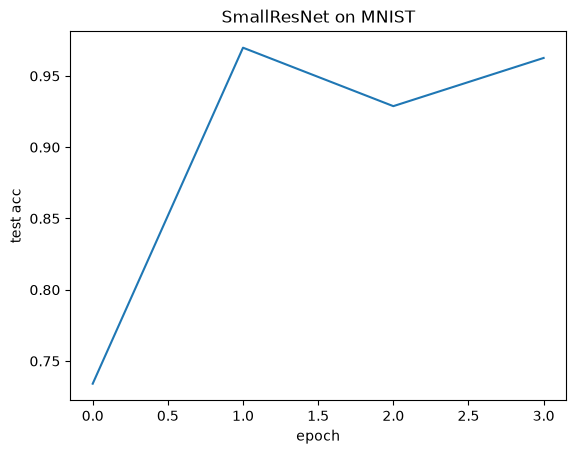

final test accuracy: 0.9626
(use the full dataset - drop num_train - and a few epochs to pass ~99%)


In [3]:
plt.plot(history["val_acc"]); plt.xlabel("epoch"); plt.ylabel("test acc")
plt.title("SmallResNet on MNIST"); plt.show()
print("final test accuracy:", history["val_acc"][-1])
print("(use the full dataset - drop num_train - and a few epochs to pass ~99%)")

### Things to tweak
- `num_blocks` (depth) and `channels` (width). More blocks = the skip connection
  earning its keep. Try `num_blocks=0` vs `8`.
- Swap to Fashion-MNIST: `mnist_loaders(..., fashion=True)`.

### Maps to raccoon
`azl.foundations.blocks.ConvTrunk` (input conv + residual blocks) is reused verbatim
by `azl.network.AZNet` when `trunk="resnet"` - i.e. the block you just trained on
digits is the block that will power the Connect-Four agent in B4, and it mirrors
raccoon's 6x128 residual trunk.